# Cardio Performance Analysis

# Cardio Performance Analysis

In this notebook, I will explore the cardio customer dataset.  
I will calculate descriptive statistics, create charts, study relationships between variables, and build a simple linear regression model.

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# This makes graphs look nicer
sns.set_style("whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


## Load the Dataset

First, I will load the dataset and check the first few rows to understand the data.

In [5]:
# Load the dataset
# Make sure your CSV file is in the same folder as your Jupyter Notebook

df = pd.read_csv("dataset-1.csv")

# Show first 5 rows
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,TM195,18,Male,14,Single,3,4,29562,112
1,TM195,19,Male,15,Single,2,3,31836,75
2,TM195,19,Female,14,Partnered,4,3,30699,66
3,TM195,19,Male,12,Single,3,3,32973,85
4,TM195,20,Male,13,Partnered,4,2,35247,47


In [6]:
# Check basic information
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nInformation about the dataset:")
df.info()

Shape of dataset: (180, 9)

Column names:
Index(['Product', 'Age', 'Gender', 'Education', 'MaritalStatus', 'Usage',
       'Fitness', 'Income', 'Miles'],
      dtype='object')

Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [7]:
# Summary statistics for numeric columns
df.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


## Task 1: The Wealth Gap

In this task, I will calculate the mean, median, and mode for the Income column.

- Mean = average income
- Median = middle income
- Mode = most common income

If the mean is higher than the median, it usually means the data is right-skewed, which means a few high incomes are pulling the average upward.

In [9]:
# Mean, Median, Mode for Income
income_mean = df["Income"].mean()
income_median = df["Income"].median()
income_mode = df["Income"].mode()[0]

print("Mean Income:", income_mean)
print("Median Income:", income_median)
print("Mode Income:", income_mode)

Mean Income: 53719.57777777778
Median Income: 50596.5
Mode Income: 45480


### Analysis

Now I will compare the mean and median to understand whether the income data is skewed.

In [10]:
# Simple skew explanation
if income_mean > income_median:
    print("The income data appears to be right-skewed.")
    print("This means a few customers with very high income pull the average up.")
    print("The median is probably a better measure of the typical customer's wealth.")
elif income_mean < income_median:
    print("The income data appears to be left-skewed.")
else:
    print("The income data appears to be roughly symmetric.")

The income data appears to be right-skewed.
This means a few customers with very high income pull the average up.
The median is probably a better measure of the typical customer's wealth.


## Task 2: The 5-Number Summary for Miles

I will calculate:
- Minimum
- Q1
- Median
- Q3
- Maximum

I will also calculate:
- Range = Max - Min
- IQR = Q3 - Q1

Then I will create a boxplot to check for outliers.

In [11]:
# 5-number summary for Miles
miles_min = df["Miles"].min()
miles_q1 = df["Miles"].quantile(0.25)
miles_median = df["Miles"].median()
miles_q3 = df["Miles"].quantile(0.75)
miles_max = df["Miles"].max()

miles_range = miles_max - miles_min
miles_iqr = miles_q3 - miles_q1

print("Five-number summary for Miles")
print("Minimum:", miles_min)
print("Q1:", miles_q1)
print("Median:", miles_median)
print("Q3:", miles_q3)
print("Maximum:", miles_max)

print("\nRange:", miles_range)
print("IQR:", miles_iqr)

Five-number summary for Miles
Minimum: 21
Q1: 66.0
Median: 94.0
Q3: 114.75
Maximum: 360

Range: 339
IQR: 48.75


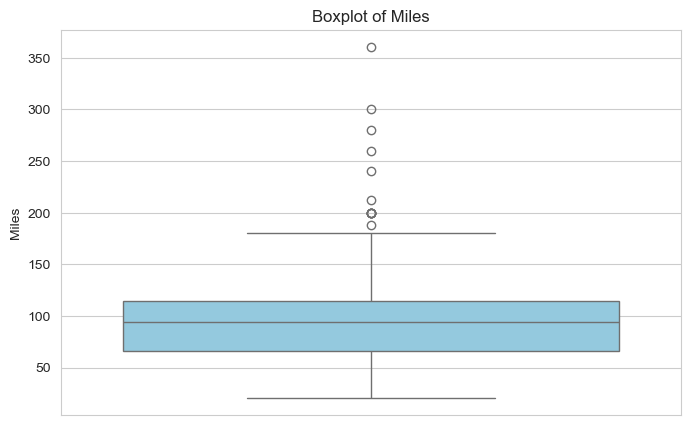

In [12]:
# Boxplot for Miles
plt.figure(figsize=(8,5))
sns.boxplot(y=df["Miles"], color="skyblue")

plt.title("Boxplot of Miles")
plt.ylabel("Miles")
plt.show()

In [13]:
# Check outliers using IQR rule
lower_bound = miles_q1 - 1.5 * miles_iqr
upper_bound = miles_q3 + 1.5 * miles_iqr

outliers = df[(df["Miles"] < lower_bound) | (df["Miles"] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))

outliers[["Miles"]]

Lower bound: -7.125
Upper bound: 187.875
Number of outliers: 13


,Miles
23,188
84,212
142,200
148,200
152,200
155,240
166,300
167,280
170,260
171,200


## Task 3: Age Distribution

I will create a histogram with 10 bins to show the distribution of age.  
Then I will check where the median age falls.

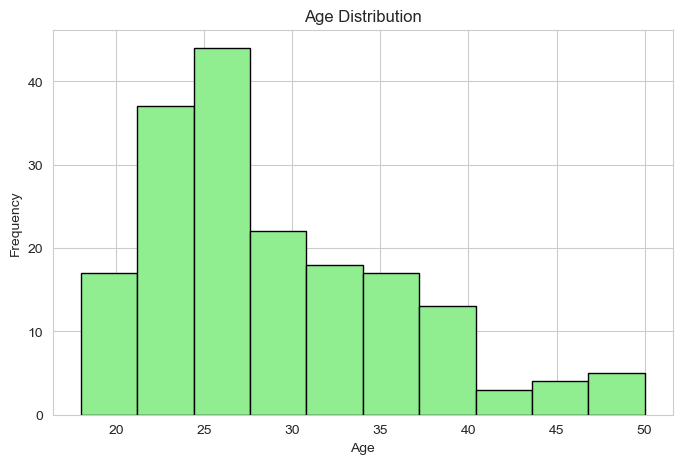

In [14]:
# Histogram for Age
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=10, color="lightgreen", edgecolor="black")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [15]:
# Median age
age_median = df["Age"].median()
print("Median Age:", age_median)

Median Age: 26.0


### Analysis

The median age tells us the middle age in the dataset.  
To answer the question, I will identify the 5-year age bracket where the median falls.

In [16]:
# Find the 5-year bracket of median age
lower_age = int(age_median // 5) * 5
upper_age = lower_age + 5

print("The median falls in the age bracket:", str(lower_age) + "-" + str(upper_age))

The median falls in the age bracket: 25-30


## Task 4: Product Popularity

I will create a count plot to see how many customers bought each product.

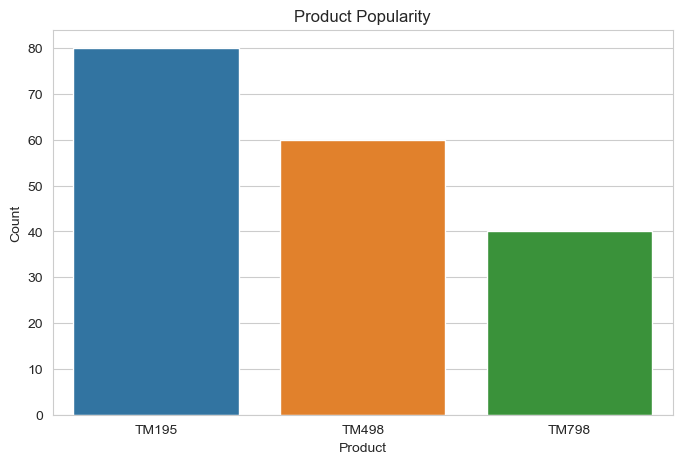

Product
TM195    80
TM498    60
TM798    40
Name: count, dtype: int64


In [18]:
# Count plot for Product
plt.figure(figsize=(8,5))
sns.countplot(x="Product", data=df, hue="Product")

plt.title("Product Popularity")
plt.xlabel("Product")
plt.ylabel("Count")
plt.show()

print(df["Product"].value_counts())

## Task 5: Income vs Product

I will compare the Income distribution across the three products using a boxplot.
This helps identify which product is targeted at high-income customers.

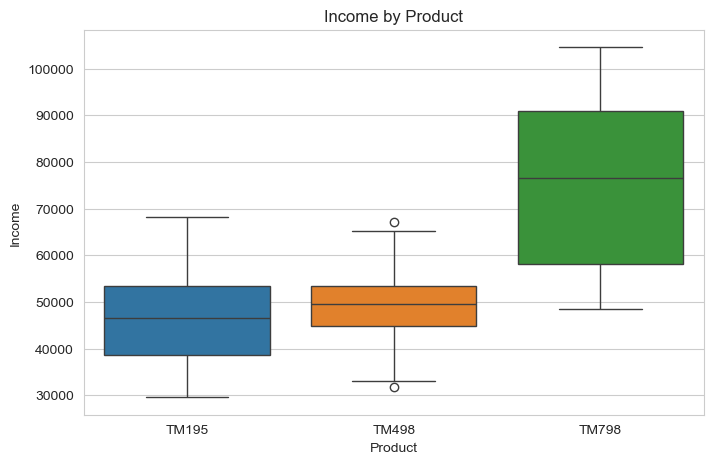

In [20]:
# Boxplot of Income by Product
plt.figure(figsize=(8,5))
sns.boxplot(x="Product", y="Income", data=df, hue="Product")

plt.title("Income by Product")
plt.xlabel("Product")
plt.ylabel("Income")
plt.show()

In [21]:
# Average income by product
income_by_product = df.groupby("Product")["Income"].mean()
print(income_by_product)

Product
TM195    46418.025
TM498    48973.650
TM798    75441.575
Name: Income, dtype: float64


### Analysis

The product with the highest income distribution is the one targeted at the high-income segment.

In [22]:
# Find product with highest average income
high_income_product = income_by_product.idxmax()
print("The product targeted at the high-income segment is:", high_income_product)

The product targeted at the high-income segment is: TM798


## Task 6: The Gender Probability

I need to calculate the probability that a customer is Female given that they bought TM195.

Formula:

P(Female | TM195) = Number of females who bought TM195 / Total number of TM195 buyers

In [23]:
# Check gender values first
print(df["Gender"].unique())

['Male' 'Female']


In [24]:
# Filter TM195 buyers
tm195 = df[df["Product"] == "TM195"]

# Count females among TM195 buyers
female_tm195 = len(tm195[tm195["Gender"] == "Female"])
total_tm195 = len(tm195)

prob_female_given_tm195 = female_tm195 / total_tm195

print("Number of females who bought TM195:", female_tm195)
print("Total TM195 buyers:", total_tm195)
print("P(Female | TM195) =", prob_female_given_tm195)
print("Percentage =", prob_female_given_tm195 * 100)

Number of females who bought TM195: 40
Total TM195 buyers: 80
P(Female | TM195) = 0.5
Percentage = 50.0


## Task 7: Correlation Heatmap

Now I will create a correlation heatmap for all numerical variables.
This shows which variables move together.

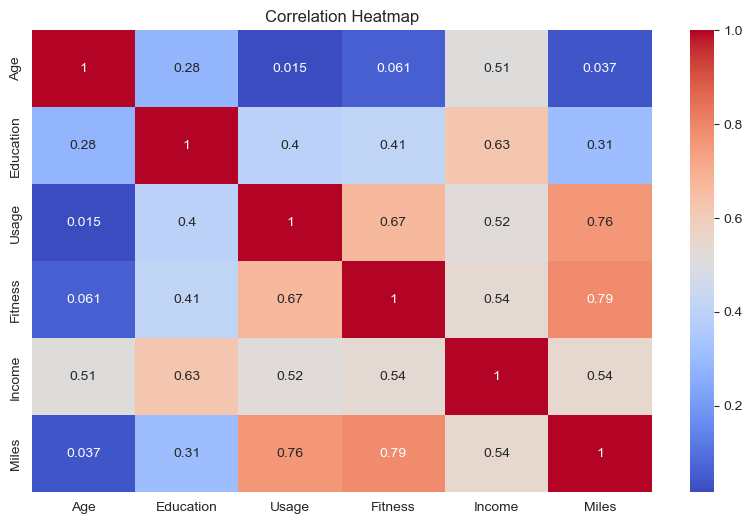

In [25]:
# Select numeric columns
numeric_df = df.select_dtypes(include=["number"])

# Correlation matrix
corr = numeric_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [26]:
# Check correlation with Miles
print(corr["Miles"].sort_values(ascending=False))

Miles        1.000000
Fitness      0.785702
Usage        0.759130
Income       0.543473
Education    0.307284
Age          0.036618
Name: Miles, dtype: float64


### Analysis

The variable with the strongest positive correlation with Miles is the one with the highest positive value after Miles itself.

In [27]:
# Compare only Age, Education, Usage with Miles
print("Correlation of Age with Miles:", corr.loc["Age", "Miles"])
print("Correlation of Education with Miles:", corr.loc["Education", "Miles"])
print("Correlation of Usage with Miles:", corr.loc["Usage", "Miles"])

Correlation of Age with Miles: 0.03661756905827155
Correlation of Education with Miles: 0.30728428208077674
Correlation of Usage with Miles: 0.7591304767293796


## Task 8: Scatter Plot with Regression Line

I will create a scatter plot of Usage vs Miles and add a regression line.
This helps show whether more usage is associated with more miles.

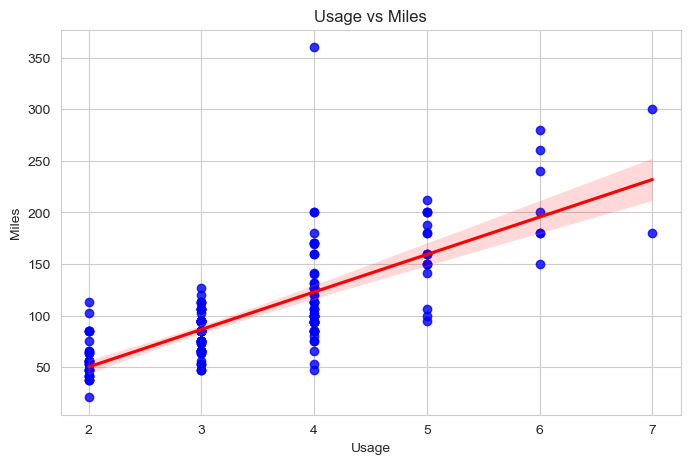

In [28]:
# Scatter plot with regression line
plt.figure(figsize=(8,5))
sns.regplot(x="Usage", y="Miles", data=df, scatter_kws={"color":"blue"}, line_kws={"color":"red"})

plt.title("Usage vs Miles")
plt.xlabel("Usage")
plt.ylabel("Miles")
plt.show()

## Linear Regression Model

Now I will train a simple linear regression model to predict Miles based on Usage.

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [30]:
# Prepare X and y
X = df[["Usage"]]
y = df["Miles"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Slope: 36.74285714285715
Intercept: -26.47142857142859
R2 Score: 0.3068295048444708
RMSE: 49.03931020699854


## Final Task: Elite Athlete Profile

Now I will create a subset containing only customers with Fitness = 5 and calculate their average Age, Education, and Income.

In [31]:
# Subset for Fitness score 5
elite = df[df["Fitness"] == 5]

elite.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
23,TM195,24,Female,16,Partnered,5,5,44343,188
61,TM195,34,Male,16,Single,4,5,51165,169
141,TM798,22,Male,16,Single,3,5,54781,120
142,TM798,22,Male,18,Single,4,5,48556,200
143,TM798,23,Male,16,Single,4,5,58516,140


In [32]:
# Average profile
print("Average Age:", elite["Age"].mean())
print("Average Education:", elite["Education"].mean())
print("Average Income:", elite["Income"].mean())

Average Age: 29.806451612903224
Average Education: 17.06451612903226
Average Income: 74396.70967741935


## Conclusion

In this notebook, I explored customer income, age, product popularity, and relationships between variables.  
I found that Usage has a strong positive relationship with Miles, and I built a simple regression model to predict Miles based on Usage.  
I also created an average profile of elite athletes with Fitness score 5.